In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
data.shape

(7043, 21)

In [ ]:
for col in data.columns:
    print(col, ":", data[col].unique())

customerID : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender : ['Female' 'Male']
SeniorCitizen : [0 1]
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank tr

In [ ]:
for col in data.columns:
    print("\n", col)
    print(data[col].value_counts())


 customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

 gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

 SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

 Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

 tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

 PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

 MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Nam

In [ ]:
data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
data['tenure'].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [ ]:
data['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


In [ ]:
pd.crosstab(data['Contract'], data['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


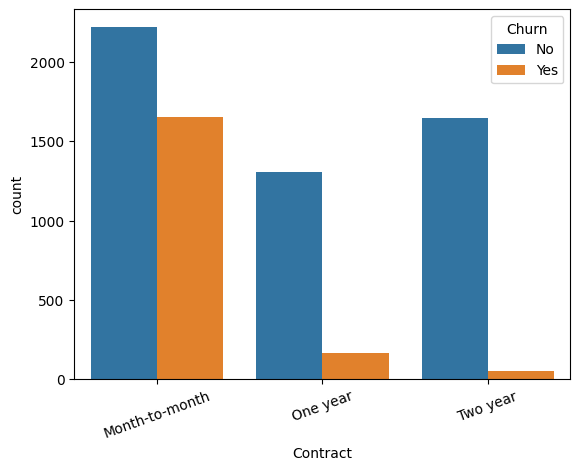

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=data)
plt.xticks(rotation=20)
plt.show()

In [ ]:
pd.crosstab(data['Contract'], data['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
pd.crosstab(data['tenure'] == 0, data['Churn'])

Churn,No,Yes
tenure,,
False,5163,1869
True,11,0


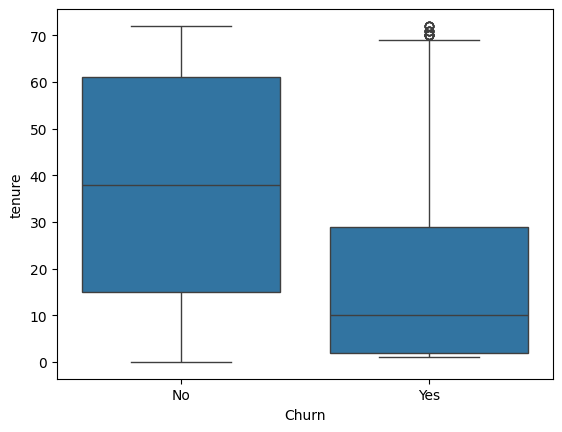

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=data)
plt.show()

In [ ]:
pd.crosstab(data['InternetService'], data['Churn'])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


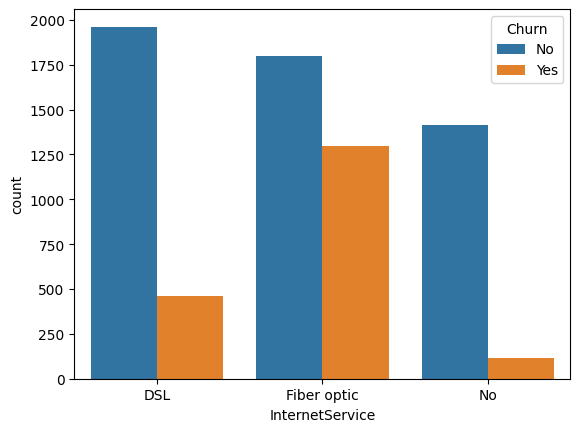

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=data)
plt.show()

In [ ]:
pd.crosstab(data['InternetService'], data['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [ ]:
pd.crosstab(data['PaymentMethod'], data['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


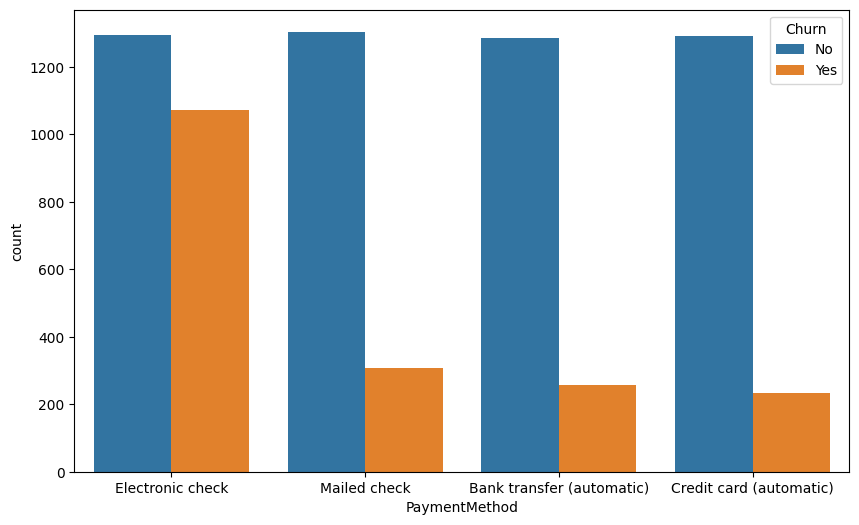

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=data)
plt.show()

In [ ]:
pd.crosstab(data['PaymentMethod'], data['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
pd.crosstab(data['TechSupport'], data['Churn'])

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


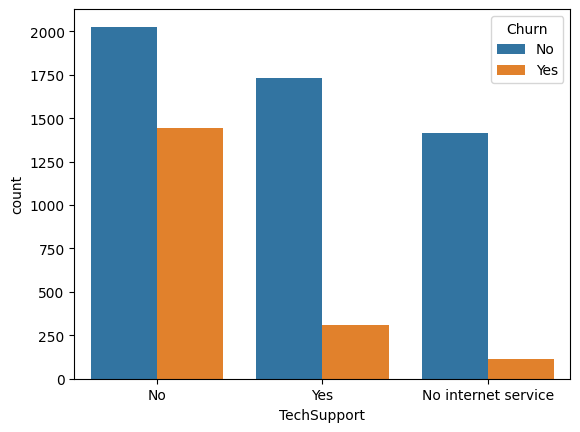

In [ ]:
sns.countplot(x='TechSupport', hue='Churn', data=data)
plt.show()

In [ ]:
pd.crosstab(data['TechSupport'], data['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [ ]:
data['tenure_group'] = pd.cut(data['tenure'],
                             bins=[0,12,24,48,72],
                             labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

In [ ]:
pd.crosstab(data['tenure_group'], data['Churn'])

Churn,No,Yes
tenure_group,,
0-1yr,1138,1037
1-2yr,730,294
2-4yr,1269,325
4-6yr,2026,213


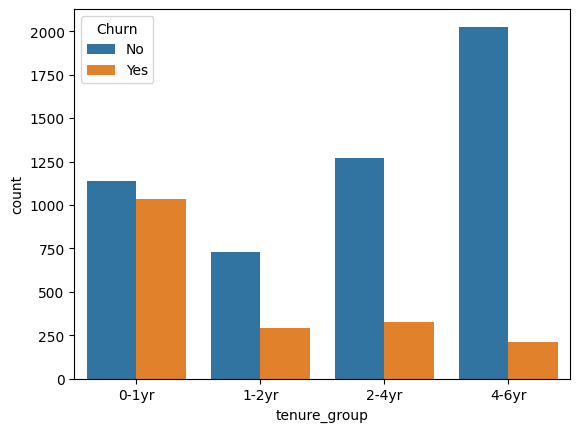

In [ ]:
sns.countplot(x='tenure_group', hue='Churn', data=data)
plt.show()

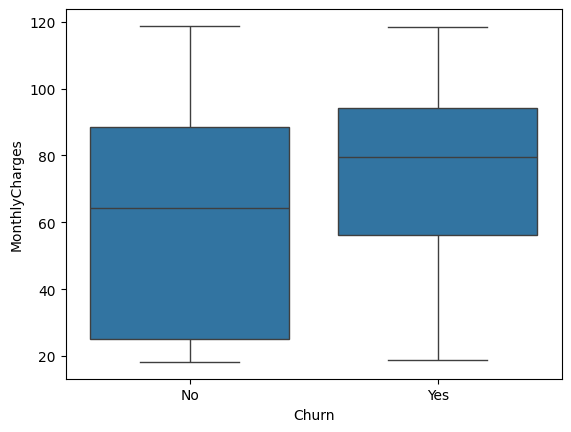

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.show()

In [ ]:
data['TotalCharges_num'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

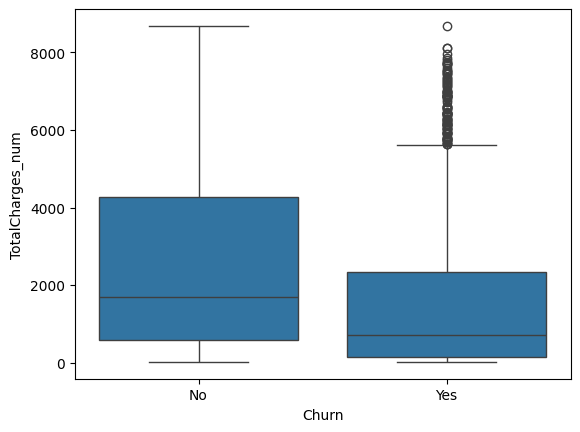

In [ ]:
sns.boxplot(x='Churn', y='TotalCharges_num', data=data)
plt.show()

In [ ]:
services = ['OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

for col in services:
    data[col] = data[col].replace({'No internet service':'No'})

In [ ]:
data['TotalServices'] = (data[services] == 'Yes').sum(axis=1)

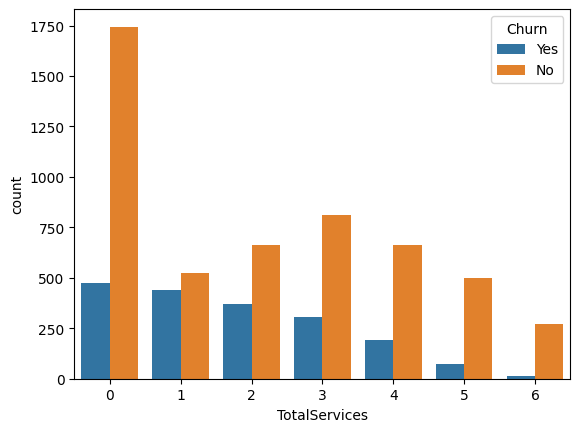

In [ ]:
sns.countplot(x='TotalServices', hue='Churn', data=data)
plt.show()

In [ ]:
pd.crosstab(data['SeniorCitizen'], data['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


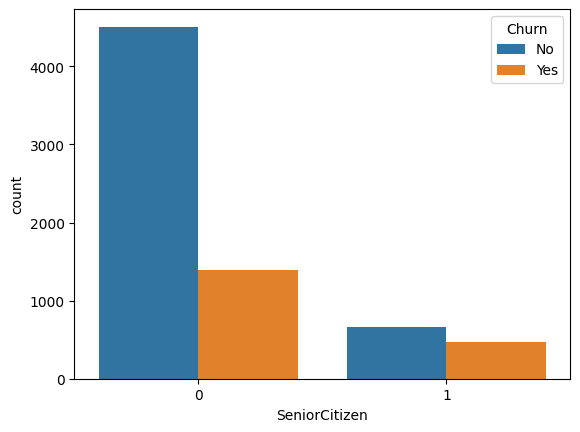

In [ ]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=data)
plt.show()

In [ ]:
pd.crosstab(data['SeniorCitizen'], data['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [ ]:
pd.crosstab(data['Dependents'], data['Churn'])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326


In [ ]:
pd.crosstab(data['Partner'], data['Churn'])

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


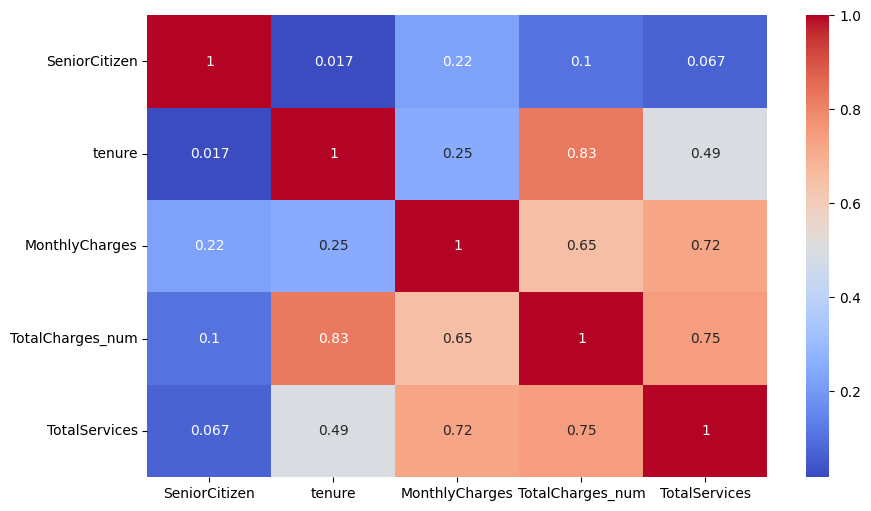

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

**Data** **Cleaning**

In [ ]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [ ]:
data['TotalCharges'].dtype

dtype('float64')

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
cols = ['MultipleLines','OnlineSecurity','OnlineBackup',
        'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in cols:
    data[col] = data[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

In [ ]:
for col in cols:
    print(col, ":", data[col].unique())

MultipleLines : ['No' 'Yes']
OnlineSecurity : ['No' 'Yes']
OnlineBackup : ['Yes' 'No']
DeviceProtection : ['No' 'Yes']
TechSupport : ['No' 'Yes']
StreamingTV : ['No' 'Yes']
StreamingMovies : ['No' 'Yes']


In [ ]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
data['Churn'].unique()

array([0, 1])

In [ ]:
data.drop('customerID', axis=1, inplace=True)

In [ ]:
'customerID' in data.columns

False

In [ ]:
data_encoded = pd.get_dummies(data, drop_first=True)

In [ ]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   TotalCharges_num                       7032 non-null   float64
 6   TotalServices                          7032 non-null   int64  
 7   gender_Male                            7032 non-null   bool   
 8   Partner_Yes                            7032 non-null   bool   
 9   Dependents_Yes                         7032 non-null   bool   
 10  PhoneService_Yes                       7032 non-null   bool   
 11  MultipleL

**Visualization**

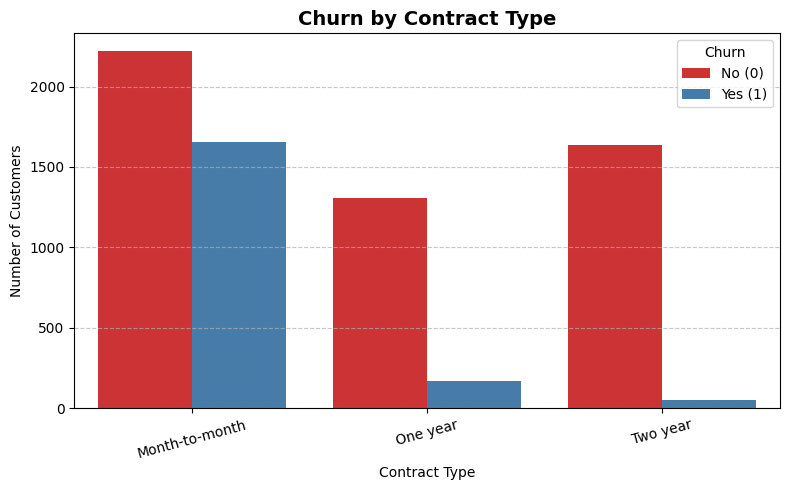

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=data, palette='Set1')

plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Churn', labels=['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_4583/4207071707.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=data, palette='Set2')


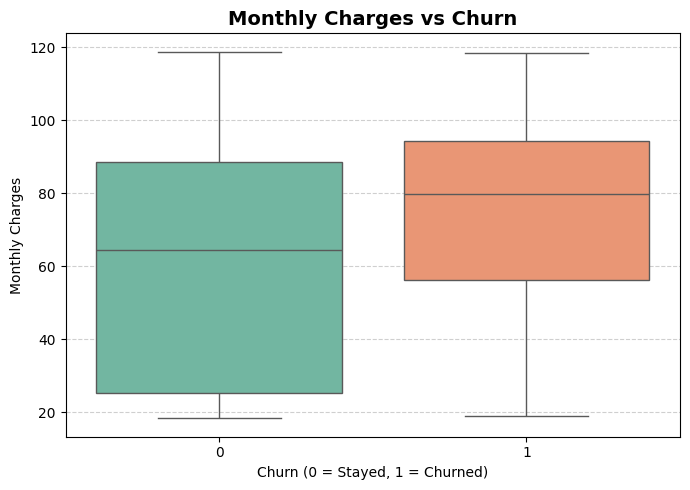

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=data, palette='Set2')

plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Monthly Charges')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

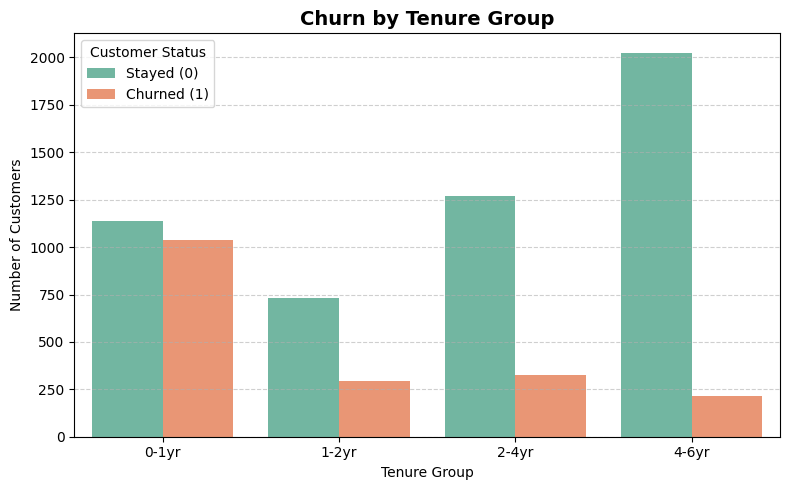

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='tenure_group', hue='Churn', data=data, palette='Set2')

plt.title('Churn by Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.legend(title='Customer Status', labels=['Stayed (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()

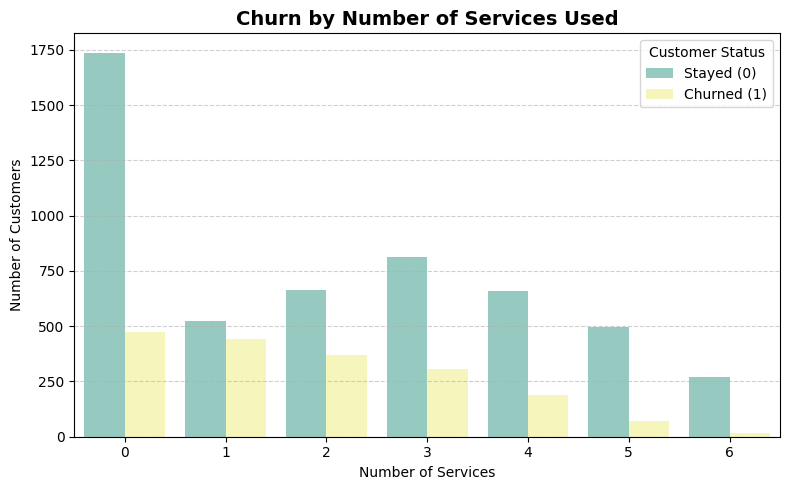

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='TotalServices', hue='Churn', data=data, palette='Set3')

plt.title('Churn by Number of Services Used', fontsize=14, fontweight='bold')
plt.xlabel('Number of Services')
plt.ylabel('Number of Customers')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.legend(title='Customer Status', labels=['Stayed (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()

In [163]:
data.to_csv('cleaned_data.csv', index=False)

In [164]:
import pickle
with open('cleaned_data.pkl', 'wb') as f:
    pickle.dump(data, f)